# Basics of Bonds Valuation:

This notebook provides a practical walkthrough of bond valuation, demonstrating how to compute fair value, clean price, and dirty price for US Treasury bonds using Python. For a detailed explanation of the pricing framework and theoretical background, see the accompanying documentation in [01_Basics_Bond_Valuation.md](../documentation/01_Basics_Bond_Valuation.md).


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
# === Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import os
import sys


In [2]:
src_path = os.path.abspath(os.path.join(os.getcwd(),"../"))
sys.path.append(src_path)
try:
    from src.bond_math import *
    from src.Bond import *
    from src.utils import *
    from src.risk_measures import *
    from src.rates_models import *
    from src.visualize import * 
    
except ImportError as e:
    print('Custom modules not found. Please ensure src/ is available.')
    print('ImportError:', e)  

## Example 1: A bond with a flat yield curve with valuation date on the coupon payment date 

Bond Cash Flows:
    cash_flow  time_years
1         3.0         0.5
2         3.0         1.0
3         3.0         1.5
4         3.0         2.0
5         3.0         2.5
6         3.0         3.0
7         3.0         3.5
8         3.0         4.0
9         3.0         4.5
10      103.0         5.0

Bond Price: $104.38

Cash flows data:

    cash_flow  time_years  discount_factor
1         3.0         0.5         0.975610
2         3.0         1.0         0.951814
3         3.0         1.5         0.928599
4         3.0         2.0         0.905951
5         3.0         2.5         0.883854
6         3.0         3.0         0.862297
7         3.0         3.5         0.841265
8         3.0         4.0         0.820747
9         3.0         4.5         0.800728
10      103.0         5.0         0.781198


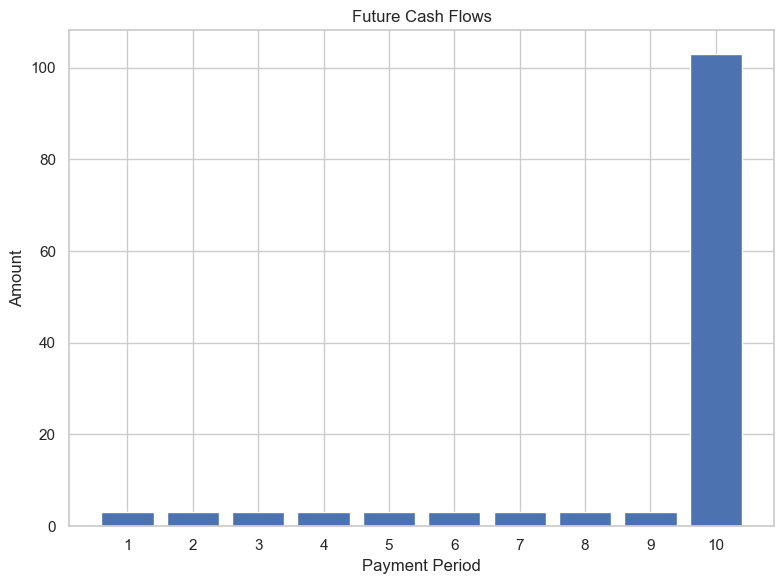

In [4]:
# Example 1: Bond pricing on coupon payment date (flat yield curve)

# Bond parameters
maturity = 5  # years
principal = 100
coupon_rate = 0.06  # 6% annual coupon
coupon_per_year = 2  # semiannual
interest_rate = 0.05  # 5% flat yield

# Generate cash flows
cash_flows = bond_cash_flows(maturity, principal, coupon_rate, coupon_per_year)
print("Bond Cash Flows:")
print(cash_flows)
print()

# Calculate bond price
price, cash_flow = bond_price_elementary(maturity, principal, coupon_rate, coupon_per_year, interest_rate)
print(f"Bond Price: ${price:.2f}")
print()
print("Cash flows data:\n")
print(cash_flow)

# Plot CashFlows 

plot_cash_flows(cash_flows['cash_flow'])

## Example 2: A bond with a flat yield curve with settlement date between two coupon payments

- Testing the coupon schedule function;
- Calculating the dirty price, the accrual and the clean price. 

2024-01-15      2.5
2024-07-15      2.5
2025-01-15      2.5
2025-07-15      2.5
2026-01-15    102.5
dtype: float64


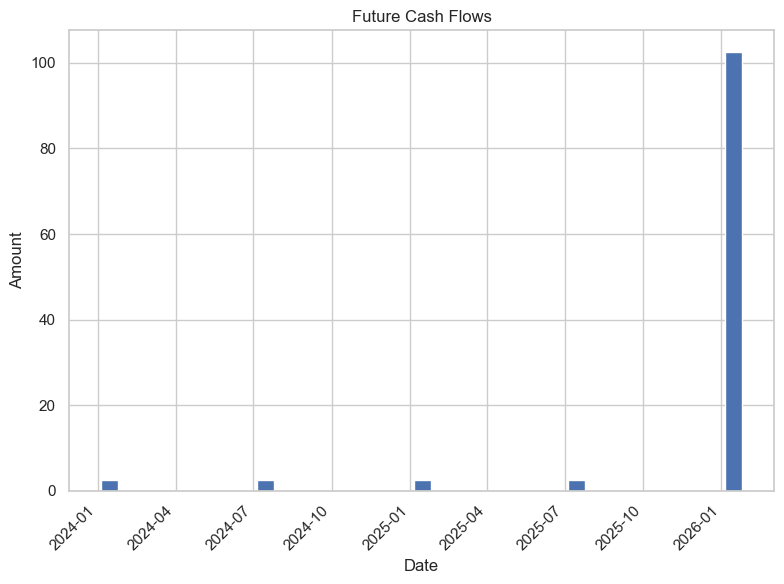

In [5]:
# Example parameters
settlement_date = "2024-01-01"
maturity_date = "2026-01-15"
coupon_days = ["01-15", "07-15"]  # Semiannual coupons: Jan 15 and Jul 15
principal = 100
coupon_rate = 0.05  # 5% annual coupon
freq = 2

schedule = coupon_schedule(
    settlement_date,
    maturity_date,
    coupon_days,
    principal=principal,
    coupon_rate=coupon_rate,
    freq=freq
)
print(schedule)

plot_cash_flows(schedule)

In [6]:
# Calculating the dirty price, the accrual and the clean price of  a bond with the parameters below
settlement_date = pd.to_datetime("2000-01-27")
maturity_date = pd.to_datetime("2001-06-15")
coupon_days = ["06-15", "12-15"]
principal = 100
coupon_rate = 0.055
freq = 2
interest_rate = 0.061
convention = "actual/actual"

bond_price  = bond_price_flat(maturity_date, coupon_days, settlement_date, 
                              principal, coupon_rate, freq, 
                              interest_rate, convention)


print("Dirty Price (shifted periods): \n")

print(bond_price)


Dirty Price (shifted periods): 

                     0
Dirty Price  99.855262
Clean Price  99.208552
Accrual       0.646710


## Example 3: Bootstrapping spot rates from par yields of coupon bonds

    tenor_years  par_yield  spot_rate
0           0.5       3.00     3.0000
1           1.0       3.30     3.3025
2           1.5       3.50     3.5053
3           2.0       3.90     3.9163
4           2.5       4.40     4.4376
5           3.0       4.70     4.7520
6           3.5       4.90     4.9622
7           4.0       5.00     5.0650
8           4.5       5.10     5.1700
9           5.0       5.20     5.2772
10          5.5       5.30     5.3864
11          6.0       5.40     5.4976
12          6.5       5.50     5.6108
13          7.0       5.55     5.6643
14          7.5       5.60     5.7193
15          8.0       5.65     5.7755
16          8.5       5.70     5.8331
17          9.0       5.80     5.9584
18          9.5       5.90     6.0863
19         10.0       6.00     6.2169


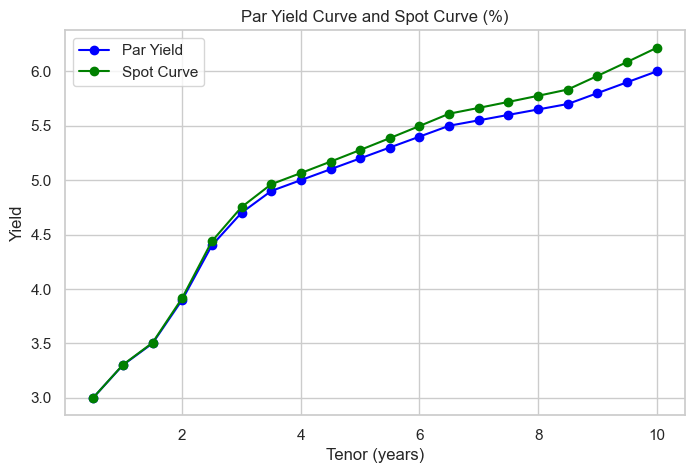

In [7]:
# Example 1: All par yields are available. No need to interpolate

years = [
    0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
    5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0
]
# par_yields in decimals
par_yields = [
    0.0300, 0.0330, 0.0350, 0.0390, 0.0440, 0.0470, 0.0490, 0.0500, 0.0510, 0.0520,
    0.0530, 0.0540, 0.0550, 0.0555, 0.0560, 0.0565, 0.0570, 0.0580, 0.0590, 0.0600
]

par_yield_df = pd.DataFrame({'tenor_years': years, 'par_yield': par_yields}).set_index('tenor_years')


# Direct bootstrapping: 
spot_curve = bootstrap_spot_rates(par_yield_df)


yield_curves = par_yield_df.reset_index().merge(
    spot_curve.reset_index(), on='tenor_years', how='left'
)
yield_curves['par_yield'] = (yield_curves['par_yield'] * 100).round(4)
yield_curves['spot_rate'] = (yield_curves['spot_rate'] * 100).round(4)
print(yield_curves)


# Display spot curve and par yield curve


fig, ax = plt.subplots(figsize=(8, 5))

# Plot interpolated par yield curve


ax.plot(yield_curves['tenor_years'], yield_curves['par_yield'], label='Par Yield', color='blue', marker ='o')

# Plot spot curve on the same axes
ax.plot(yield_curves['tenor_years'], yield_curves['spot_rate'], label='Spot Curve', color='green', marker='o')

ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Yield')
ax.set_title('Par Yield Curve and Spot Curve (%)')
ax.legend()
ax.grid(True)
plt.show()

    tenor_years  par_yield  spot_rate
0           0.5     3.6000     3.6000
1           1.0     4.0000     4.0040
2           1.5     4.0500     4.0537
3           2.0     4.1000     4.1044
4           2.5     4.3000     4.3125
5           3.0     4.5000     4.5226
6           3.5     4.6875     4.7216
7           4.0     4.8750     4.9231
8           4.5     5.0625     5.1275
9           5.0     5.2500     5.3352
10          5.5     5.4375     5.5465
11          6.0     5.6250     5.7618
12          6.5     5.8125     5.9815
13          7.0     6.0000     6.2062
14          7.5     6.1667     6.4091
15          8.0     6.3333     6.6171
16          8.5     6.5000     6.8309
17          9.0     6.6667     7.0510
18          9.5     6.8333     7.2781
19         10.0     7.0000     7.5130


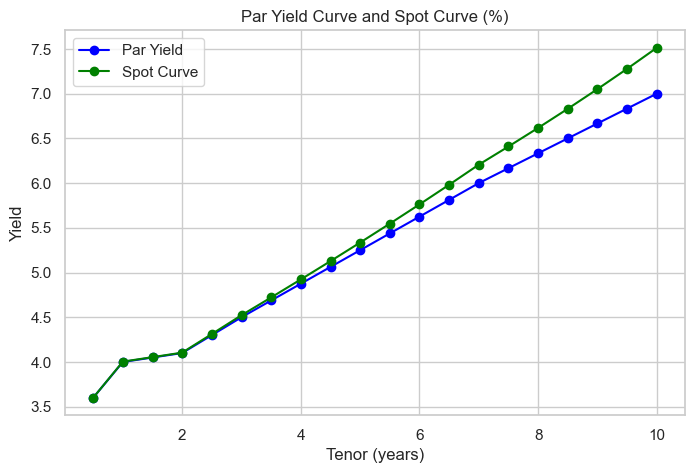

In [8]:
# Example 2: Only standard par yields are available. Need to interpolate first 


standard_tenors = [0.5, 1.0, 2.0, 3.0, 7.0, 10.0]
standard_par_yields = [0.0360, 0.040, 0.041, 0.045, 0.060, 0.070]

par_yield_standard = pd.DataFrame({
    'tenor_years': standard_tenors, 
    'par_yield':standard_par_yields
}).set_index('tenor_years')


# Interpolate par yields
par_yield_complete = interpolate_par_yields(par_yield_standard)

# Bootstrap the spot curve
spot_curve_1 = bootstrap_spot_rates(par_yield_complete)

yield_curves_1 = par_yield_complete.reset_index().merge(
    spot_curve_1.reset_index(), on='tenor_years', how='left'
)
yield_curves_1['par_yield'] = (yield_curves_1['par_yield'] * 100).round(4)
yield_curves_1['spot_rate'] = (yield_curves_1['spot_rate'] * 100).round(4)
print(yield_curves_1)

# Display spot curve and par yield curve

fig, ax = plt.subplots(figsize=(8, 5))


# Plot interpolated par yield curve

ax.plot(yield_curves_1['tenor_years'], yield_curves_1['par_yield'], label='Par Yield', color='blue', marker ='o')

# Plot spot curve on the same axes
ax.plot(yield_curves_1['tenor_years'], yield_curves_1['spot_rate'], label='Spot Curve', color='green', marker='o')

ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Yield')
ax.set_title('Par Yield Curve and Spot Curve (%)')
ax.legend()
ax.grid(True)
plt.show()

## Example 4: Calculating the price of a bond using spot rates 

In [9]:
# Example 4.1: We assume that valuation date is the settlment date; no accural. 

price, cf = bond_price_from_par_yields(10, par_yield_df, 100, 0.08, 2)

In [10]:
# Example 4.2: Calculate bond price using full_bond_price_from_par_yields with convention where valuation date is between 
# two coupon payments


# Define bond parameters
settlement_date = pd.Timestamp('2024-01-01')
maturity_date = pd.Timestamp('2026-01-15')
coupon_days = ['01-15', '07-15']
principal = 100
coupon_rate = 0.05
freq = 2
convention = 'actual/actual'
par_yields = pd.Series({
    0.5: 0.03,
    1.0: 0.033,
    1.5: 0.035,
    2.0: 0.039,
    2.5: 0.044
})
par_yields.index.name = 'tenor_years'
par_yields = par_yields.to_frame('par_yield')

# Run the bond price calculation
price_df, cash_flows_df = full_bond_price_from_par_yields(
    maturity_date, par_yields, coupon_days, settlement_date, principal, coupon_rate, freq, convention
 )

print('Bond Price Summary:')
print(price_df)
print('\nCash Flows and Discounting:')
print(cash_flows_df)

Bond Price Summary:
                     0
Dirty Price  97.006900
Clean Price  94.696637
Accrual       2.310263

Cash Flows and Discounting:
            cash_flow  time_years  spot_rate  discount_factor       pv
2024-01-15        2.5    0.038251   0.030000         0.997743   2.4944
2024-07-15        2.5    0.535519   0.030215         0.968250   2.4206
2025-01-15        2.5    1.038356   0.033180         0.933967   2.3349
2025-07-15        2.5    1.534247   0.035334         0.897865   2.2447
2026-01-15      102.5    2.038356   0.039163         0.853779  87.5123


# Example 5: Calculating the price of a bond using par yield data from the US Treasury market

We will retrieve the par yield data from the US Treasury market on the valuation date and use it to calculate the price of a bond with a given coupon rate and maturity. 

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Bond characteristics
settlement_date = pd.to_datetime("2022-12-01")
maturity_date = pd.to_datetime("2028-01-03")
coupon_days = ["01-03", "04-03", "07-03", "10-03"]
principal = 100
coupon_rate = 0.04
freq = 4
convention = "actual/actual"

In [13]:
# Step 1: Retrieve the par yield data (or the latest available par yields)
data_path = '../data/par-yield-curve-rates-1990-2023.csv'

# Remark: yields_df are in %. The conversion to decimals is performed inside get_yields_on_date
yields_df = load_yield_curve_data(data_path)

available_yields, missing, used_date = get_yields_on_date(yields_df, settlement_date)




 Yield Curve for 2022-12-01 (original request: 2022-12-01):
Available tenors:
             par_yield
tenor_years           
0.083333        0.0404
0.166667        0.0424
0.250000        0.0433
0.333333        0.0452
0.500000        0.0465
1.000000        0.0466
2.000000        0.0425
3.000000        0.0398
5.000000        0.0368
7.000000        0.0362
10.000000       0.0353
20.000000       0.0385
30.000000       0.0364


/Users/fatima.ezzahra.jabiri/Desktop/BondPricer/src/utils.py:18: UserWarning: Warning: the par yields are in %!
  warnings.warn("Warning: the par yields are in %!")
/Users/fatima.ezzahra.jabiri/Desktop/BondPricer/src/utils.py:64: UserWarning: The yields have been converted to decimals. 
  warnings.warn("The yields have been converted to decimals. ")


In [14]:
# Step 2: Apply the full_bond_price_from_par_yield

price_df, cash_flows_df = full_bond_price_from_par_yields(
    maturity_date, available_yields, coupon_days, used_date, principal, coupon_rate, freq, convention
)
print("Bond Price Summary:")
print(price_df)
print("\nCash Flows and Discounting:")
print(cash_flows_df)

Bond Price Summary:
                     0
Dirty Price  62.019400
Clean Price  61.378096
Accrual       0.641304

Cash Flows and Discounting:
            cash_flow  time_years  spot_rate  discount_factor       pv
2023-01-03        1.0    0.090411   0.045199         0.984007   0.9840
2023-04-03        1.0    0.336986   0.045219         0.940735   0.9407
2023-07-03        1.0    0.586301   0.046517         0.896652   0.8967
2023-10-03        1.0    0.838356   0.046560         0.856005   0.8560
2024-01-03        1.0    1.090396   0.046228         0.818455   0.8185
2024-04-03        1.0    1.339030   0.045185         0.786018   0.7860
2024-07-03        1.0    1.587664   0.044142         0.756429   0.7564
2024-10-03        1.0    1.839030   0.043088         0.729515   0.7295
2025-01-03        1.0    2.090411   0.042158         0.704309   0.7043
2025-04-03        1.0    2.336986   0.041476         0.679662   0.6797
2025-07-03        1.0    2.586301   0.040784         0.656831   0.6568
2025-10

## Example 6: Testing the bond pricer on a bond object

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Create a Bond instance
bond = Bond(
    identifier="TestBond",
    issue_date="2023-01-01",
    maturity_date="2028-01-01",
    settlement_date="2026-02-27",
    coupon_rate=0.05,
    notional=1000,
    freq=2,
    coupon_days=["01-01", "07-01"]
)

# Display bond summary
bond.display_bond()

# Show cash flows
print("Cash Flows:")
print(bond.cash_flows())

# Price the bond with a flat yield
print("Price (flat 3%):")
print(bond.price(interest_rate=0.03))


Bond Summary - TestBond
-------------------------------
Issue Date:        2023-01-01
Settlement Date:   2026-02-27
Maturity Date:     2028-01-01
Coupon:            5.00% (paid 2x per year)
Notional:          $1,000
Observed Price:       -
-------------------------------
Cash Flows:
2026-07-01      25.0
2027-01-01      25.0
2027-07-01      25.0
2028-01-01    1025.0
dtype: float64
Price (flat 3%):
                       0
Dirty Price  1043.424679
Clean Price  1035.551750
Accrual         7.872928
